# Compute metrics

F1, recall, precision, mean IoU, mean Dice, PQ

Save metrics as:

results/experiment_metrics.csv


In [1]:
1+1

2

In [2]:
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from copy import deepcopy
import skimage
import scipy
import basicpy
from tqdm import tqdm

import sys
sys.path.append('/home/icb/lion.gleiter/projects/organoid_sam/SAM_with_Detection_Head')

from util.box_ops_numpy import mask_to_boxes, cxcywh_to_xyxy, xyxy_to_cxcywh, plot_boxes
from util import dataloading as dl

%load_ext autoreload
%autoreload 2

In [3]:
# model = 'MicroSAM_*'
# embed_base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_embeddings2')

# for file in tqdm(embed_base.glob(f'{model}/*/*/*/*')):
#     stem = file.stem
#     if stem.startswith('images_patches_emb_'):
#         continue
#     patch_num = int(stem.removeprefix('patch_'))
#     new_stem = f'images_patches_emb_{patch_num:04d}'
#     new_file = file.with_stem(new_stem)
#     file.rename(new_file)
#     # print(file)
#     # print(new_file)
#     # if i >= 0:
#     #     break

In [4]:
# Patches in Neurips train, val and organoID train / val / test
125904 / 3

41968.0

In [5]:
embed_base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_embeddings2')
print('# patches in NeurIPS train:', len(list(embed_base.glob(f'MicroSAM_huge/train/NeurIPSCellSeg_train/*/*.npy'))))

# patches in NeurIPS train: 10940


In [3]:
base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')
organoid_sam = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


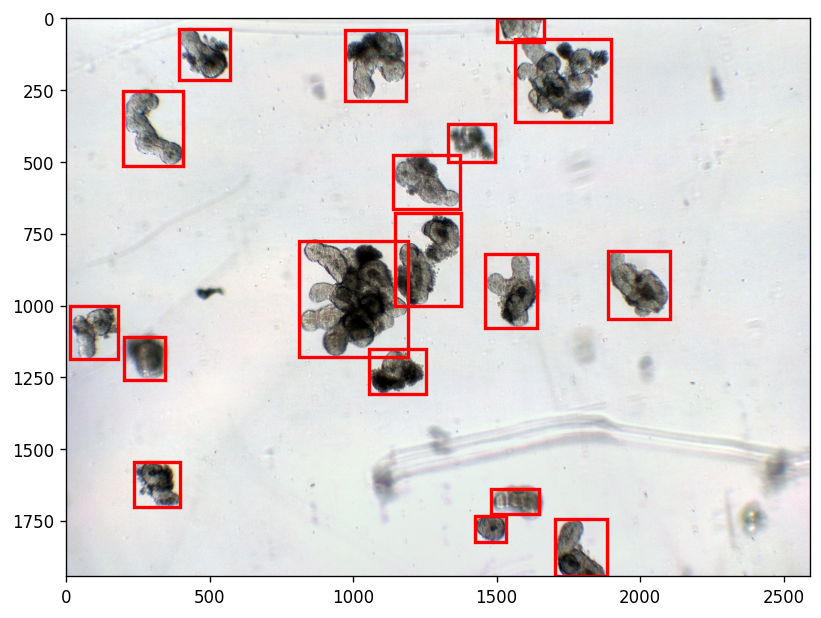

In [7]:
ds = dl.OrganoID(split='test_only_mouse')
im, mask, boxes, im_path, im_ID = ds[3]
im, flatfield = dl.normalize(im)

plot_boxes(im, boxes, format='yxyx_px')

In [4]:
def convert_mask_to_binary(mask):
    assert mask.ndim == 2, mask.shape
    masks = []
    for j in sorted(np.unique(mask).astype(int).tolist()):
        if j == 0:  # background
            continue
        masks.append((mask == j).reshape((-1, mask.shape[0], mask.shape[1])))
    if len(masks) == 0:
        return np.array([], dtype=bool).reshape((-1, mask.shape[0], mask.shape[1]))
    else:
        return np.stack(masks, axis=0).reshape((-1, mask.shape[0], mask.shape[1]))

def get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID):
    box_folder = organoid_sam / 'patch_bbox_gt' / split / ds_name / f'im_{im_ID}'
    img_folder = organoid_sam / 'patch_images' / split / ds_name / f'im_{im_ID}'
    mask_folder = organoid_sam / 'patch_seg_gt' / split / ds_name / f'im_{im_ID}'
    assert box_folder.exists(), box_folder
    assert img_folder.exists(), img_folder
    assert mask_folder.exists(), mask_folder

    offsets = np.load(box_folder / 'offsets.npy')

    pred_boxes = []
    pred_scores = []
    pred_masks = []
    for patch_number, offset_y, offset_x in offsets:
        patch_img = cv2.imread(str(img_folder / f'patch_{patch_number}.png'))
        H, W = patch_img.shape[:2]
        pred_boxes_patch = np.load(box_folder / f'patch_{patch_number}.npy')
        pred_boxes_patch = cxcywh_to_xyxy(pred_boxes_patch) * max(H, W) + np.array([[offset_y, offset_x, offset_y, offset_x]])
        pred_boxes.append(pred_boxes_patch)

        pred_scores.append(np.random.uniform(0, 1, pred_boxes_patch.shape[0]) + 1)

        pred_masks_patch = np.load(mask_folder / f'patch_{patch_number}.npy')
        labels = np.zeros((im.shape[0], im.shape[1]), dtype=pred_masks_patch.dtype)
        labels[offset_y:offset_y+pred_masks_patch.shape[0], offset_x:offset_x+pred_masks_patch.shape[1]] = pred_masks_patch
        # for i in sorted(np.unique(labels).astype(int).tolist()):
        #     if i == 0:  # background
        #         continue
        #     mask = labels == i
        #     pred_masks.append(mask)
        pred_masks.append(convert_mask_to_binary(labels))

    pred_boxes = np.concatenate(pred_boxes, axis=0)
    pred_scores = np.concatenate(pred_scores, axis=0)
    pred_masks = np.concatenate(pred_masks, axis=0)
    # pred_masks = np.stack(pred_masks, axis=0)

    return offsets, pred_boxes, pred_scores, pred_masks


# /ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM_large/test/OrganoID_test/DetectionHead_SAM_large_OrganoID_train_default_best
def get_predictions(split, ds_name, pred_folder, im, im_ID):
    base = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/OrgaSegment_test_data/eval/OrganoidBasic20211215')
    results_df = pd.read_csv(base / 'results.csv')
    results_df = results_df[results_df.name == im_ID].sort_values('id')

    boxes = [(b.y1, b.x1, b.y2, b.x2) for b in results_df.itertuples(index=False)]
    pred_boxes = np.array(boxes).astype(float).reshape((-1, 4))

    pred_scores = results_df.score.values

    labels = cv2.imread(str(base / f'{im_ID}_masks_class-1.png'), cv2.IMREAD_GRAYSCALE)

    pred_masks = convert_mask_to_binary(labels)

    return pred_boxes, pred_scores, pred_masks

In [9]:
offsets, pred_boxes, pred_scores, pred_masks = get_pseudo_predictions('test', f'{str(ds)}_{ds.split}', im, mask, boxes, im_path, im_ID)

In [10]:
pred_masks.shape

(35, 1022, 1024)

In [9]:
pred_folder = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/patch_predictions/SAM_large/test/OrganoID_test/DetectionHead_SAM_large_OrganoID_train_default_best')
pred_boxes, pred_scores, pred_masks = get_predictions('test', f'{str(ds)}_{ds.split}', pred_folder, im, im_ID)

In [11]:
pred_boxes.shape

(10, 4)

In [12]:
pred_masks.shape

(10, 1944, 2592)

In [13]:
np.unique(pred_masks)

array([False,  True])

In [14]:
pred_scores

array([0.99892384, 0.99862778, 0.99856985, 0.99794716, 0.99575269,
       0.9920032 , 0.96554935, 0.91451019, 0.88003498, 0.80298829])

In [15]:
pred_masks.sum() / 400

526.22

In [16]:
(pred_masks.sum(axis=(1, 2)) < 100).sum()

0

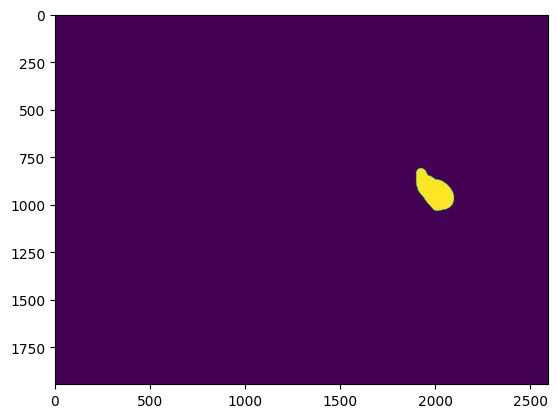

In [17]:
plt.imshow((pred_masks[2]).astype(int) * 255)

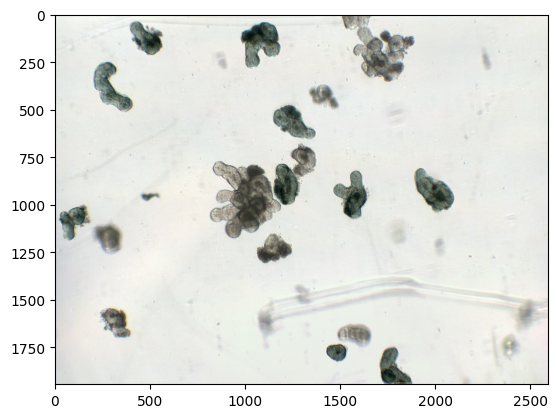

In [18]:
plt.imshow(im)
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255, alpha=0.2, cmap='YlGn')

In [19]:
im_ID

'image0017'

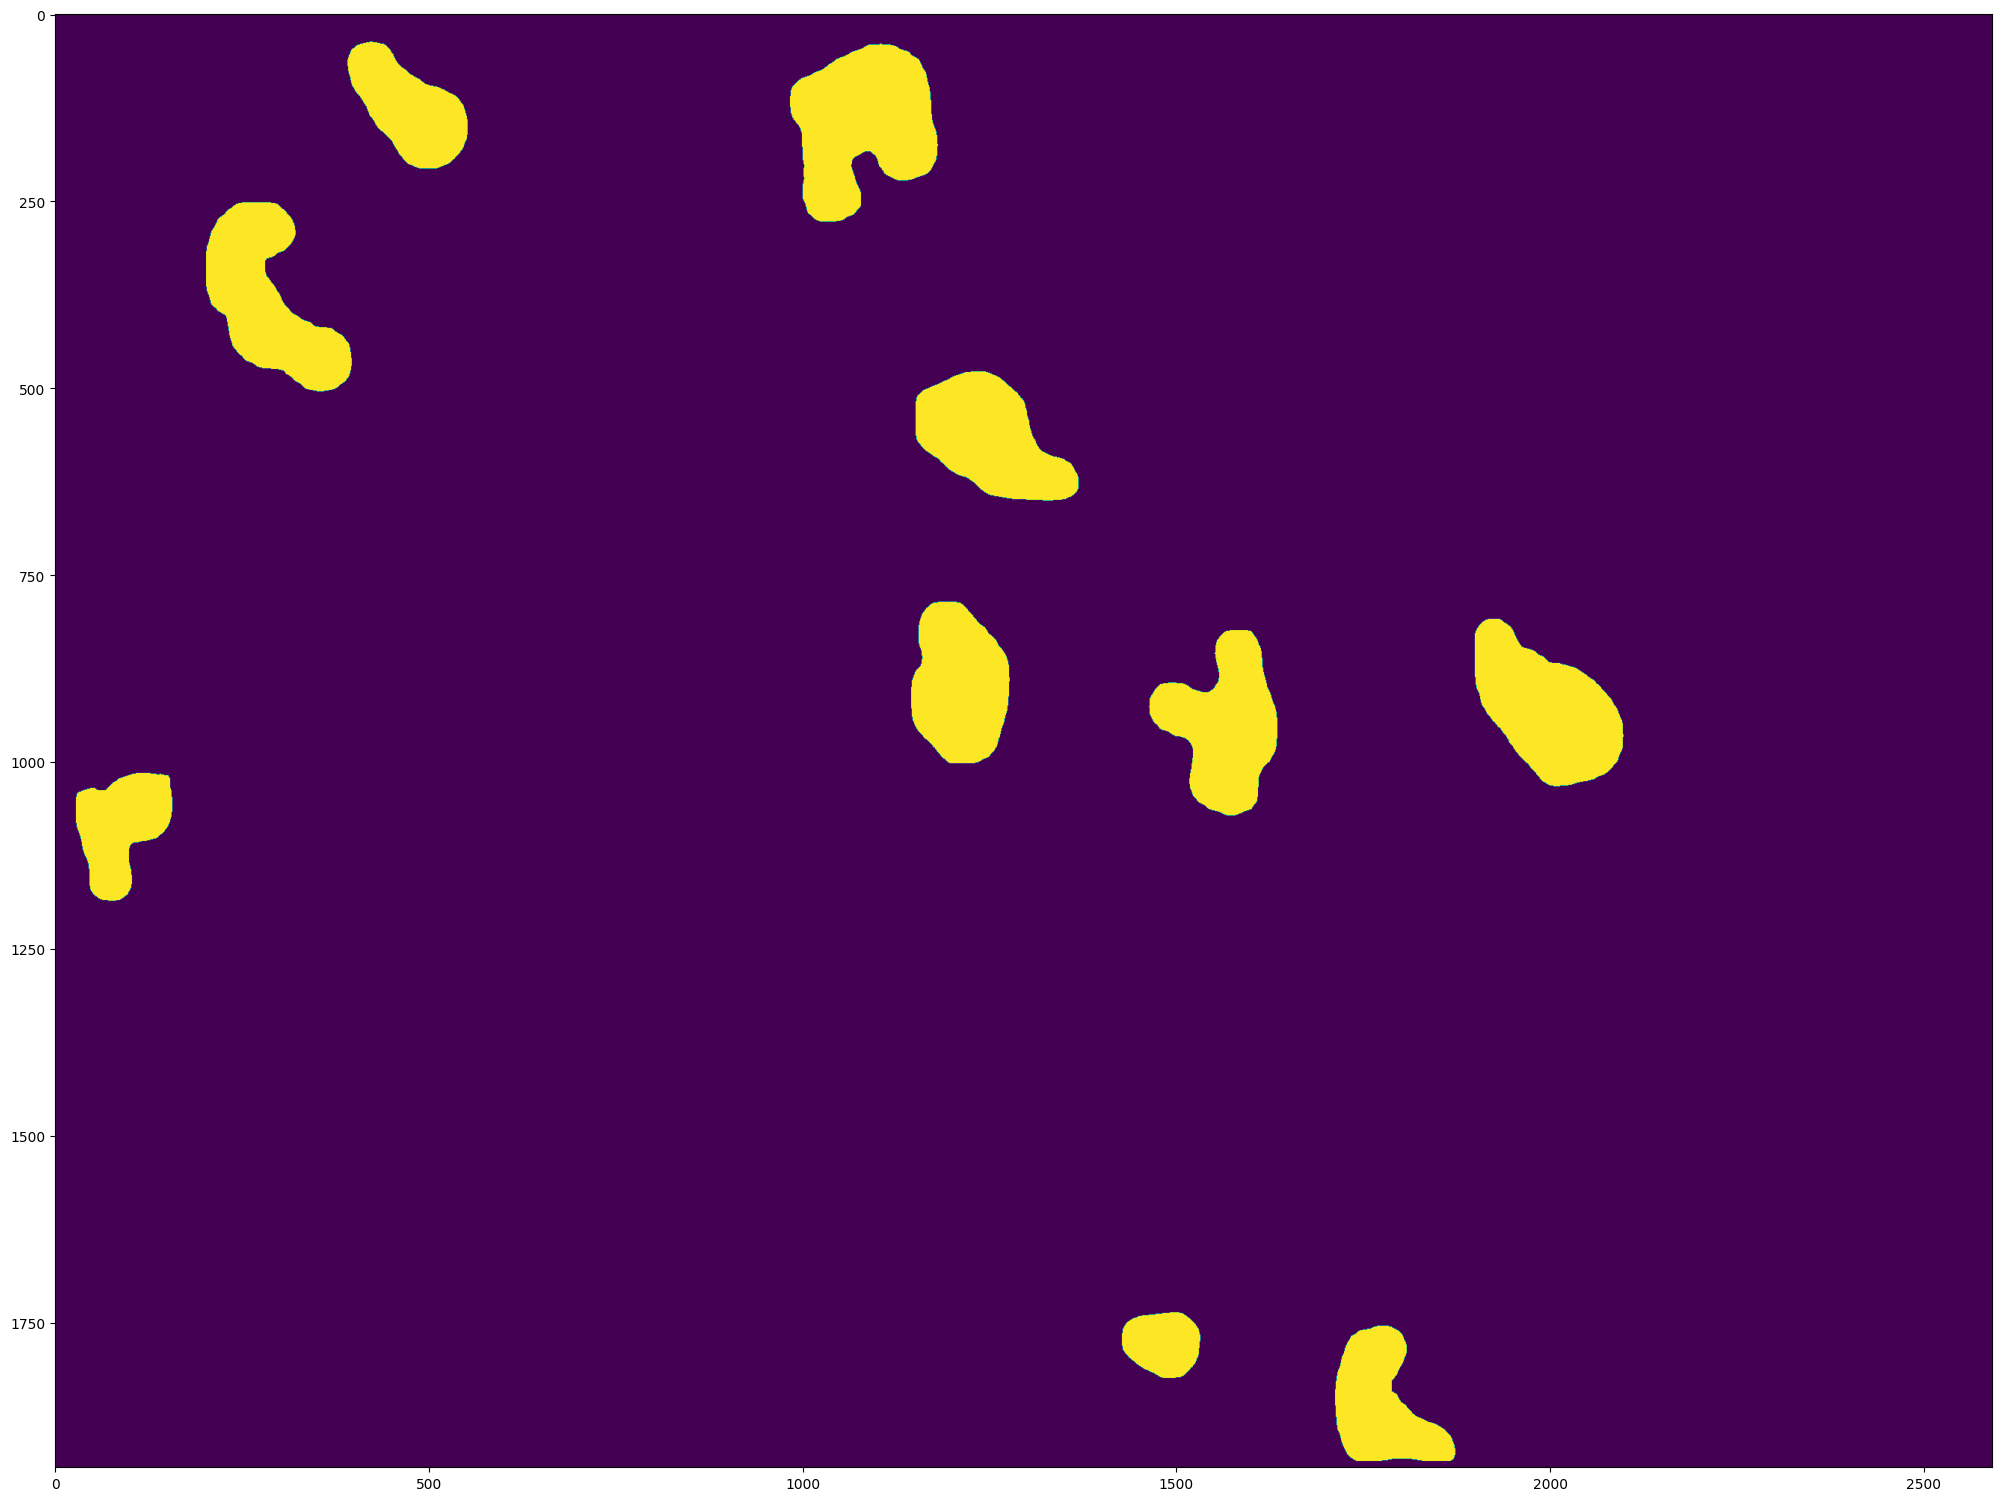

In [20]:
plt.figure(figsize=(25, 25))
plt.imshow(np.any(pred_masks, axis=0).astype(int) * 255)

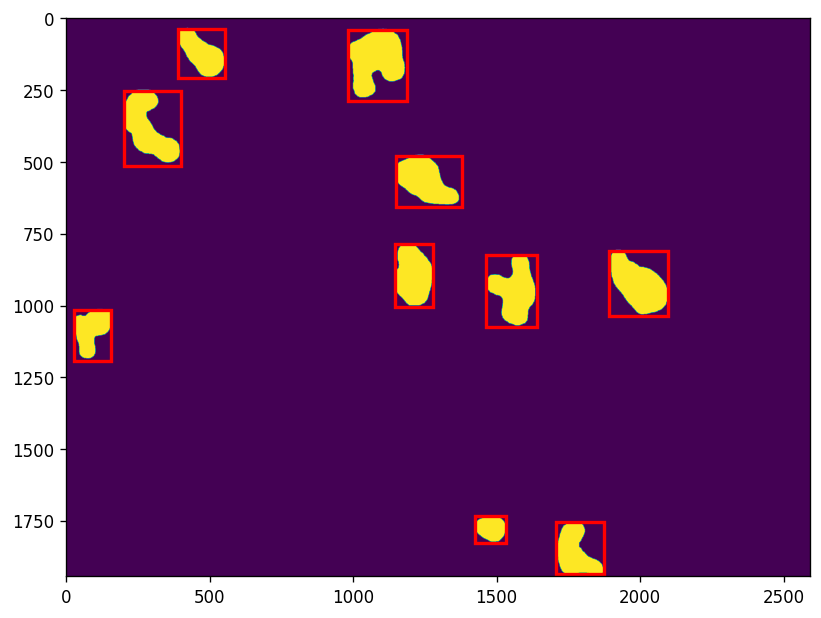

In [21]:
# plot_boxes(im, pred_boxes[pred_scores > 0.5], format='yxyx_px')
plot_boxes(np.any(pred_masks[pred_scores > 0.5], axis=0).astype(int) * 255, pred_boxes[pred_scores > 0.5], format='yxyx_px')
# plt.imshow(im)

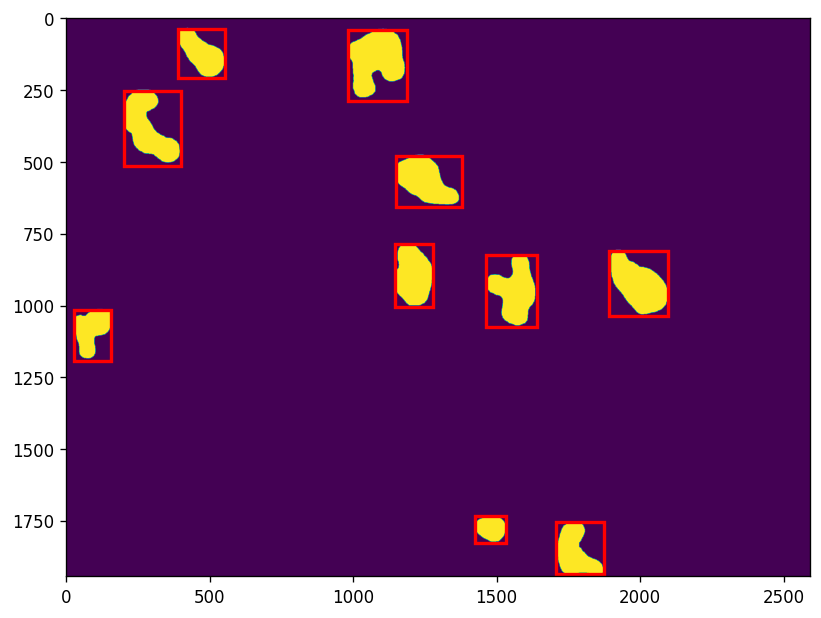

In [22]:
plot_boxes(np.any(pred_masks, axis=0).astype(int) * 255, pred_boxes, format='yxyx_px')

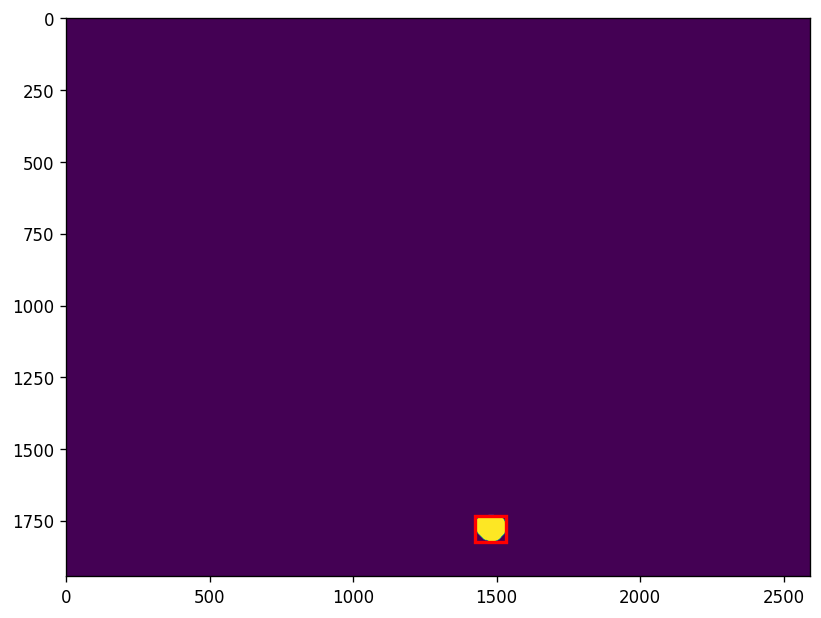

In [23]:
i = -2

masks = convert_mask_to_binary(mask)

plot_boxes(masks[i], boxes[i:i+1], format='yxyx_px')

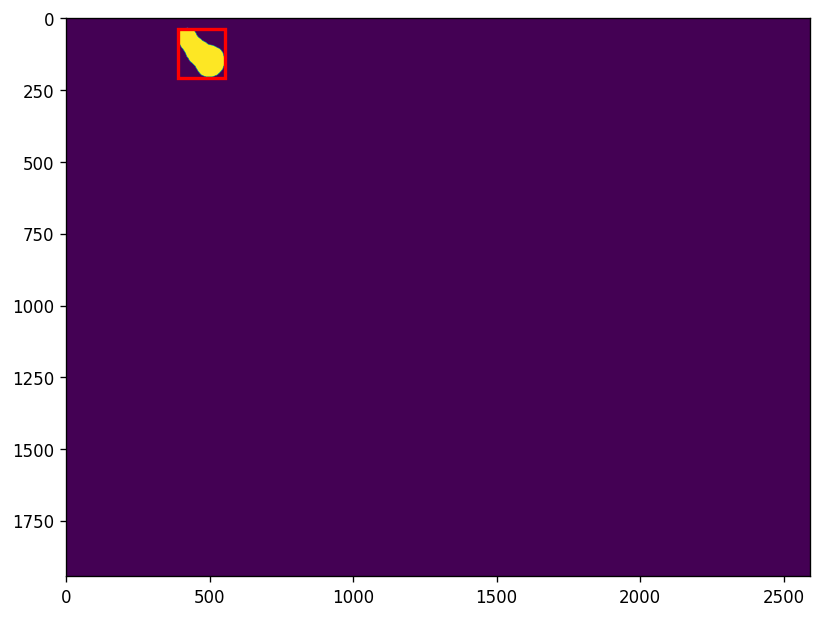

In [24]:
i = 4

plot_boxes(pred_masks[i], pred_boxes[i:i+1], format='yxyx_px')

### Define necessary functions here

In [5]:
import os
from PIL import Image
import numpy as np
import cv2
from copy import deepcopy
from typing import Tuple


# NMS
def iou_box_array(box, boxes):

    box = np.array(box).astype(float)
    boxes = np.array(boxes).astype(float)

    assert boxes.ndim==2, boxes.shape
    assert boxes.shape[1]==4, boxes.shape
    x_left = np.maximum(box[0], boxes[:, 0])
    x_right = np.minimum(box[2], boxes[:, 2])
    y_left = np.maximum(box[1], boxes[:, 1])
    y_right = np.minimum(box[3], boxes[:, 3])

    intersection = np.maximum(x_right - x_left, 0) * np.maximum(y_right - y_left, 0)

    area = (box[2] - box[0]) * (box[3] - box[1]) + (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

    assert np.all(area > 1), area
    # print(box, boxes)
    # print('np.minimum(box[2], boxes[:, 2])', np.minimum(box[2], boxes[:, 2]))
    # print('intersection', intersection)
    # print('area', area)
    _iou = np.where(area - intersection > 0, intersection / (area - intersection), 0.0)
    assert np.all(_iou >= 0), _iou
    assert np.all(_iou <= 1), _iou
    return _iou


# def nms(boxes, scores, embeddings, thres = 0.9):
#     boxes = np.array(boxes)
#     scores = np.array(scores)
#     embeddings = np.array(embeddings)
    
#     sorted_ind = np.argsort(scores)[::-1]
#     boxes_sorted = boxes[sorted_ind]
#     scores_sorted = scores[sorted_ind]
#     embeddings_sorted = embeddings[sorted_ind]

#     out_boxes = []
#     out_scores = []
#     out_embeddings = []
#     # ref_box, ref_score, ref_embed = boxes_sorted[0], scores_sorted[0], embeddings_sorted[0]
#     remaining_boxes, remaining_scores, remaining_embeds = boxes_sorted, scores_sorted, embeddings_sorted
#     while len(remaining_boxes) > 0:
#         ref_box, ref_score, ref_embed = remaining_boxes[0], remaining_scores[0], remaining_embeds[0]
#         remaining_boxes, remaining_scores, remaining_embeds = remaining_boxes[1:], remaining_scores[1:], remaining_embeds[1:]
        
#         out_boxes.append(ref_box)
#         out_scores.append(ref_score)
#         out_embeddings.append(ref_embed)

#         ious = iou(ref_box, remaining_boxes)

#         remaining_boxes = remaining_boxes[ious < thres]
#         remaining_scores = remaining_scores[ious < thres]
#         remaining_embeds = remaining_embeds[ious < thres]

#     return np.array(out_boxes), np.array(out_scores), np.array(out_embeddings)




def non_max_suppression(bboxes, scores, threshold):
    """Perform Non-Maximum Suppression (NMS) on bounding boxes.
    
    Args:
    bboxes (numpy.ndarray): Array of bounding boxes in the format (x1, y1, x2, y2).
    scores (numpy.ndarray): Array of scores for each bounding box.
    threshold (float): IoU threshold for suppression.

    Returns:
    numpy.ndarray: Array of indices of bounding boxes to keep.
    """
    # Sort the bounding boxes by the scores in descending order
    indices = np.argsort(scores)[::-1]
    
    keep = []
    while len(indices) > 0:
        current = indices[0]
        keep.append(current)
        
        if len(indices) == 1:
            break
        
        current_box = bboxes[current]
        remaining_boxes = bboxes[indices[1:]]
        
        # Compute IoU of the current box with the rest
        # ious = np.array([compute_iou_box(current_box, box) for box in remaining_boxes])
        ious = iou_box_array(current_box, remaining_boxes)
        
        # Select boxes with IoU less than the threshold
        indices = indices[1:][ious < threshold]
    
    return np.array(keep)

def compute_iou_box(box1, box2):
    x1_max = max(box1[0], box2[0])
    y1_max = max(box1[1], box2[1])
    x2_min = min(box1[2], box2[2])
    y2_min = min(box1[3], box2[3])

    intersection_area = max(0, x2_min - x1_max) * max(0, y2_min - y1_max)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    if union_area == 0:
        return 0.0

    iou = intersection_area / union_area
    return iou

# def transform_mask(mask):
#     """
#     Transforms a mask of shape (N, 1, H, W) into a single mask of shape (H, W),
#     where background is 0 and different masks are labeled as 1, 2, 3, ..., N.
#     If the mask contains only zeros, it returns a zero-filled mask of shape (H, W).
#     """
#     # Check if the mask is entirely zeros
#     if len(mask.shape) == 2:
#         return mask

#     # Get the number of masks
#     num_masks = mask.shape[0]
    
#     # Initialize a new mask with zeros (background)
#     transformed_mask = np.zeros((mask.shape[2], mask.shape[3]), dtype=np.uint8)

#     # Assign label 1, 2, 3, ..., N to each mask respectively
#     for i in range(num_masks):
#         single_mask = mask[i, 0, :, :]  # Extract each mask
#         transformed_mask[single_mask > 0] = i + 1  # Label the mask with 1, 2, ..., N

#     return transformed_mask

In [6]:
import os
import time
import numpy as np
from scipy.optimize import linear_sum_assignment
from skimage.measure import label

# def compute_iou(pred_mask, gt_mask, pred_label, gt_label):
#     pred_instance = (pred_mask == pred_label)
#     gt_instance = (gt_mask == gt_label)

def compute_iou_masks(pred_instance, gt_instance):
    
    intersection = np.logical_and(pred_instance, gt_instance).sum()
    union = np.logical_or(pred_instance, gt_instance).sum()
    
    if union == 0:
        return 0.0
    else:
        return intersection / union
    

def compute_iou_masks_array(pred_instance, gt_instances):
    
    intersection = np.logical_and(pred_instance[None, ...], gt_instances).sum(axis=(1, 2))
    union = np.logical_or(pred_instance[None, ...], gt_instances).sum(axis=(1, 2))
    

    iou = np.where(union > 0, intersection / union, 0.0)
    del intersection, union
    return iou



def compute_metrics_segmentation(pred_masks, gt_masks, iou_threshold=0.5):
    # pred_labels = np.unique(pred_mask)
    # gt_labels = np.unique(gt_mask)
    
    # # Remove background label (0)
    # pred_labels = pred_labels[pred_labels != 0]
    # gt_labels = gt_labels[gt_labels != 0]
    
    num_preds = pred_masks.shape[0]
    num_gts = gt_masks.shape[0]
    
    # Create the IoU matrix
    iou_matrix = np.zeros((num_preds, num_gts))
    
    # print('before iou', time.time())
    for i, pred_mask in enumerate(pred_masks):
        iou_matrix[i, :] = compute_iou_masks_array(pred_instance=pred_mask, gt_instances=gt_masks)
        # for j, gt_mask in enumerate(gt_masks):
        #     iou_matrix[i, j] = compute_iou_masks(pred_mask, gt_mask)
    
    # print('before lap', time.time())
    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
    # print('after lap', time.time())

    tp = []
    fp = []
    fn = []
    
    matched_gt = set()
    matched_pred = set()
    
    for i, j in zip(row_ind, col_ind):
        if iou_matrix[i, j] >= iou_threshold:
            tp.append(iou_matrix[i, j])
            matched_gt.add(j)
            matched_pred.add(i)
    
    for i in range(num_preds):
        if i not in matched_pred:
            fp.append(i)
    
    for j in range(num_gts):
        if j not in matched_gt:
            fn.append(j)
    
    # Calculate PQ
    pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    
    # Calculate precision, recall, and F1-score
    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate mean IoU
    mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
    # Calculate Dice coefficient
    dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    
    return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




def compute_metrics_detection(pred_boxes, gt_boxes, iou_threshold=0.5):
    
    num_preds = pred_boxes.shape[0]
    num_gts = gt_boxes.shape[0]
    
    # Create the IoU matrix
    iou_matrix = np.zeros((num_preds, num_gts))
    
    for i, pred_box in enumerate(pred_boxes):
        iou_matrix[i, :] = iou_box_array(pred_box, gt_boxes)
        # for j, gt_box in enumerate(gt_boxes):
        #     iou_matrix[i, j] = compute_iou_box(pred_box, gt_box)
    
    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
    tp = []
    fp = []
    fn = []
    
    matched_gt = set()
    matched_pred = set()
    
    for i, j in zip(row_ind, col_ind):
        if iou_matrix[i, j] >= iou_threshold:
            tp.append(iou_matrix[i, j])
            matched_gt.add(j)
            matched_pred.add(i)
    
    for i in range(num_preds):
        if i not in matched_pred:
            fp.append(i)
    
    for j in range(num_gts):
        if j not in matched_gt:
            fn.append(j)
    
    
    # Calculate precision, recall, and F1-score
    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate mean IoU
    mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
    # # Calculate Dice coefficient
    # dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    dice_coefficient = 0.0

    # # Calculate PQ
    # pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    pq = 0.0
    
    return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




def compute_iou_matrix_detection(pred_boxes, gt_boxes):
    
    num_preds = pred_boxes.shape[0]
    num_gts = gt_boxes.shape[0]
    
    # Create the IoU matrix
    iou_matrix = np.zeros((num_preds, num_gts))
    
    for i, pred_box in enumerate(pred_boxes):
        iou_matrix[i, :] = iou_box_array(pred_box, gt_boxes)

    return iou_matrix
    


def compute_metrics_detection_from_iou_matrix(iou_matrix, iou_threshold=0.5):
    
    num_preds = iou_matrix.shape[0]
    num_gts = iou_matrix.shape[1]
    
    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
    tp = []
    fp = []
    fn = []
    
    matched_gt = set()
    matched_pred = set()
    
    for i, j in zip(row_ind, col_ind):
        if iou_matrix[i, j] >= iou_threshold:
            tp.append(iou_matrix[i, j])
            matched_gt.add(j)
            matched_pred.add(i)
    
    for i in range(num_preds):
        if i not in matched_pred:
            fp.append(i)
    
    for j in range(num_gts):
        if j not in matched_gt:
            fn.append(j)
    
    
    # Calculate precision, recall, and F1-score
    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate mean IoU
    mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
    # # Calculate Dice coefficient
    # dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    dice_coefficient = 0.0

    # # Calculate PQ
    # pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    pq = 0.0
    
    return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




def compute_iou_matrix_segmentation(pred_masks, gt_masks):
    num_preds = pred_masks.shape[0]
    num_gts = gt_masks.shape[0]
    
    # Create the IoU matrix
    iou_matrix = np.zeros((num_preds, num_gts))
    
    for i, pred_mask in enumerate(pred_masks):
        iou_matrix[i, :] = compute_iou_masks_array(pred_instance=pred_mask, gt_instances=gt_masks)
        
    return iou_matrix
    

def compute_metrics_segmentation_from_iou_matrix(iou_matrix, iou_threshold=0.5):
    # pred_labels = np.unique(pred_mask)
    # gt_labels = np.unique(gt_mask)
    
    # # Remove background label (0)
    # pred_labels = pred_labels[pred_labels != 0]
    # gt_labels = gt_labels[gt_labels != 0]
    
    num_preds = iou_matrix.shape[0]
    num_gts = iou_matrix.shape[1]


    # print('before lap', time.time())
    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(-iou_matrix)
    
    # print('after lap', time.time())

    tp = []
    fp = []
    fn = []
    
    matched_gt = set()
    matched_pred = set()
    
    for i, j in zip(row_ind, col_ind):
        if iou_matrix[i, j] >= iou_threshold:
            tp.append(iou_matrix[i, j])
            matched_gt.add(j)
            matched_pred.add(i)
    
    for i in range(num_preds):
        if i not in matched_pred:
            fp.append(i)
    
    for j in range(num_gts):
        if j not in matched_gt:
            fn.append(j)
    
    # Calculate PQ
    pq = np.sum(tp) / (len(tp) + 0.5 * len(fp) + 0.5 * len(fn))
    
    # Calculate precision, recall, and F1-score
    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
    recall = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate mean IoU
    mean_iou = np.mean(tp) if len(tp) > 0 else 0
    
    # Calculate Dice coefficient
    dice_coefficient = np.mean([2 * iou / (1 + iou) for iou in tp]) if len(tp) > 0 else 0
    
    return len(tp), len(fp), len(fn), pq, precision, recall, f1_score, mean_iou, dice_coefficient




# Predict

boxes, scores and masks are saved in a folder called 'organoid_sam/patch_predictions/backbone/trainvaltest/dataset_name/checkpoint_name/image_ID/boxes_{i}.npy'

In [8]:

# NMS threshold
from tqdm import tqdm


nms_thres = 0.5

experiment_name = 'orga_segment_testset_final_evaluation'
experiment = [
    ('tbd', 'tbd', 'OrgaSegment'),
]


df = []
for split, test_data in [
    ('test', dl.OrgaSegment(split='test')),
    # ('test', dl.OrganoID(split='test')),
    #                 ('test', dl.OrganoID(split='test_Lung')),
    #                 ('test', dl.OrganoID(split='test_ACC')),
    #                 ('test', dl.OrganoID(split='test_C')),
    #                 ('test', dl.OrganoID(split='test_only_mouse'))
                    ]:
    for backbone, ckpt_name, model_name in experiment:
        optimal_thres = 0.5
        # print(optimal_thres)
        
        ds_name = f'{str(test_data)}_{test_data.split}'
        
        pred_base = organoid_sam / 'patch_predictions' / backbone / split / ds_name / ckpt_name
        for im, mask, boxes, im_path, im_ID in tqdm(test_data):
            gt_masks = convert_mask_to_binary(mask)

            # print(boxes.shape, gt_masks.shape)


            # offsets, pseudo_boxes, pseudo_scores, pseudo_masks = get_pseudo_predictions(split, ds_name, im, mask, boxes, im_path, im_ID)
            # pred_boxes, pred_scores, pred_masks = pseudo_boxes, pseudo_scores, pseudo_masks  # TODO: change
            # min_shape = min(pred_boxes.shape[0], pred_masks.shape[0])
            # pred_boxes = pred_boxes[:min_shape]
            # pred_masks = pred_masks[:min_shape]
            # pred_scores = pred_scores[:min_shape]

            # pred_boxes, pred_scores, pred_masks, is_border = get_predictions(split, ds_name, pred_base, im, im_ID)

            try:
                pred_boxes, pred_scores, pred_masks = get_predictions(split, ds_name, pred_base, im, im_ID)
            except:  # No predictions
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                            'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                            0, 0, 0, 0, 0, 0, 0, np.nan, np.nan])
                
                df.append([experiment_name, 
                            f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                            'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                            0, 0, 0, 0, 0, 0, 0, np.nan, np.nan])

                continue
        
            # print(pred_scores.shape, pred_boxes.shape, pred_masks.shape)
        
            pred_boxes = pred_boxes[pred_scores >= optimal_thres]
            pred_masks = pred_masks[pred_scores >= optimal_thres]
            pred_scores = pred_scores[pred_scores >= optimal_thres]
            
            # TODO: Remove boxes at patch borders

            # kept_indices = non_max_suppression(pred_boxes, pred_scores, threshold=nms_thres)
            # # print('after nms')

            # if len(kept_indices) != 0:
            #     pred_boxes = pred_boxes[kept_indices]
            #     pred_masks = pred_masks[kept_indices]
            #     pred_scores = pred_scores[kept_indices]

            assert pred_boxes.ndim == 2, pred_boxes.shape
            assert pred_boxes.shape[1] == 4, pred_boxes.shape
            assert pred_boxes.shape[0] == pred_masks.shape[0], pred_masks.shape
            assert pred_boxes.shape[0] == pred_scores.shape[0], pred_scores.shape

            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = compute_metrics_segmentation(pred_masks=pred_masks, 
                                                                                                                    gt_masks=gt_masks, 
                                                                                                                    iou_threshold=0.5)
            df.append([experiment_name, 
                        f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                        'segmentation', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                        tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])
            
            tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient = compute_metrics_detection(pred_boxes=pred_boxes, 
                                                                                                                gt_boxes=boxes, 
                                                                                                                iou_threshold=0.5)
            df.append([experiment_name, 
                        f'{str(test_data)}_{test_data.split}', im_ID, im_path,
                        'detection', backbone, ckpt_name, model_name, f'{optimal_thres:.2f}',
                        tp, fp, fn, pq, precision, recall, f1_score, mean_iou, dice_coefficient])

df = pd.DataFrame(data=df, columns=[
    'exp_name', 'testset', 'im_ID', 'im_path', 'metric_type', 'backbone', 'ckpt_name', 'model_name', 'confidence_thres',
    'tp', 'fp', 'fn', 'pq', 'precision', 'recall', 'f1_score', 'mean_iou', 'dice_coefficient'
])
df.to_csv(results_dir / f'{experiment_name}.csv')  # 'organoid_test_OrgaSegment_OrganoID.csv')
df

  0%|                                                                                     | 0/12 [00:00<?, ?it/s]

100%|████████████████████████████████████████████████████████████████████████████| 12/12 [09:40<00:00, 48.37s/it]


,exp_name,testset,im_ID,im_path,metric_type,backbone,ckpt_name,model_name,confidence_thres,tp,fp,fn,pq,precision,recall,f1_score,mean_iou,dice_coefficient
0,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_2013089_ckmbvhhhx0000345zlx7mhq1y_img,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,tbd,tbd,OrgaSegment,0.50,61,1,9,0.786351,0.983871,0.871429,0.924242,0.850806,0.917888
1,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_2013089_ckmbvhhhx0000345zlx7mhq1y_img,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,tbd,tbd,OrgaSegment,0.50,61,1,9,0.000000,0.983871,0.871429,0.924242,0.856074,0.000000
2,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_2423915_cknt06dr33pzv3b68t421bk27_img,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,tbd,tbd,OrgaSegment,0.50,31,2,45,0.452054,0.939394,0.407895,0.568807,0.794739,0.881221
3,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_2423915_cknt06dr33pzv3b68t421bk27_img,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,tbd,tbd,OrgaSegment,0.50,30,3,46,0.000000,0.909091,0.394737,0.550459,0.840065,0.000000
4,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_7071445_ckm384kvx8ib3345zzs8qewl4_img,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,tbd,tbd,OrgaSegment,0.50,38,4,6,0.742091,0.904762,0.863636,0.883721,0.839734,0.911663
5,orga_segment_testset_final_evaluation,OrgaSegment_test,0002_7071445_ckm384kvx8ib3345zzs8qewl4_img,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,tbd,tbd,OrgaSegment,0.50,39,3,5,0.000000,0.928571,0.886364,0.906977,0.854370,0.000000
6,orga_segment_testset_final_evaluation,OrgaSegment_test,0003_9960762_ckmdlvkmi14yv345z384v1grr_img,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,tbd,tbd,OrgaSegment,0.50,33,1,3,0.832844,0.970588,0.916667,0.942857,0.883319,0.937097
7,orga_segment_testset_final_evaluation,OrgaSegment_test,0003_9960762_ckmdlvkmi14yv345z384v1grr_img,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,tbd,tbd,OrgaSegment,0.50,33,1,3,0.000000,0.970588,0.916667,0.942857,0.868663,0.000000
8,orga_segment_testset_final_evaluation,OrgaSegment_test,20210727_11562_ckufm1p2h4vzp0y7jh0fyg2yo_img,/ictstr01/groups/shared/users/lion.gleiter/org...,segmentation,tbd,tbd,OrgaSegment,0.50,51,3,1,0.789775,0.944444,0.980769,0.962264,0.820747,0.899430
9,orga_segment_testset_final_evaluation,OrgaSegment_test,20210727_11562_ckufm1p2h4vzp0y7jh0fyg2yo_img,/ictstr01/groups/shared/users/lion.gleiter/org...,detection,tbd,tbd,OrgaSegment,0.50,51,3,1,0.000000,0.944444,0.980769,0.962264,0.811685,0.000000


In [9]:
metrics = df.groupby(['exp_name', 'testset', 'metric_type', 'backbone', 'ckpt_name', 'model_name', #'confidence_thres'
                      ], as_index=False).agg(
    pq_mean = pd.NamedAgg('pq', 'mean'), 
    precision_mean = pd.NamedAgg('precision', 'mean'), 
    recall_mean = pd.NamedAgg('recall', 'mean'), 
    f1_score_mean = pd.NamedAgg('f1_score', 'mean'), 
    mean_iou_mean = pd.NamedAgg('mean_iou', 'mean'), 
    dice_coefficient_mean = pd.NamedAgg('dice_coefficient', 'mean')
)
metrics

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,orga_segment_testset_final_evaluation,OrgaSegment_test,detection,tbd,tbd,OrgaSegment,0.000000,0.901736,0.810180,0.842019,0.846684,0.000000
1,orga_segment_testset_final_evaluation,OrgaSegment_test,segmentation,tbd,tbd,OrgaSegment,0.699017,0.903549,0.810389,0.842721,0.827406,0.903071


In [10]:
metrics.to_csv(results_dir / f'{experiment_name}_aggregated.csv') #f'organoid_test_OrgaSegment_OrganoID_aggregated.csv')

In [11]:
metrics.round(decimals=3)

,exp_name,testset,metric_type,backbone,ckpt_name,model_name,pq_mean,precision_mean,recall_mean,f1_score_mean,mean_iou_mean,dice_coefficient_mean
0,orga_segment_testset_final_evaluation,OrgaSegment_test,detection,tbd,tbd,OrgaSegment,0.000,0.902,0.81,0.842,0.847,0.000
1,orga_segment_testset_final_evaluation,OrgaSegment_test,segmentation,tbd,tbd,OrgaSegment,0.699,0.904,0.81,0.843,0.827,0.903


### Plots

In [31]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='pq_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OrgaSegment,0.604319,0.474565,0.554446,0.803212,0.450833


In [32]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='f1_score_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OrgaSegment,0.739026,0.537465,0.623289,0.886472,0.538998


In [33]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='precision_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OrgaSegment,0.861561,0.925926,0.803241,0.98808,0.727124


In [34]:
metrics[metrics.metric_type == 'segmentation'].pivot(
    index='model_name', columns='testset', values='recall_mean'
)

testset,OrganoID_test,OrganoID_test_ACC,OrganoID_test_C,OrganoID_test_Lung,OrganoID_test_mouse
model_name,,,,,
OrgaSegment,0.668257,0.431476,0.513301,0.809481,0.432419
